# Training for New Data (engine_2)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import os
import pandas as pd
import random
import yaml
import seaborn as sns

from src.electrical_signature_frequencies import ANOMALY_FREQS
from src.anomaly_injector import GaussianPeakInjector, NoiseInjector, CompositeAnomalyInjector
import matplotlib.pyplot as plt
from pathlib import Path

import torch

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Set device 
device: str = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device(device)
print("Using device:", device)

Using device: mps


## Configuration

In [3]:
base_dir = "../dataset/engine_2"

# Load Engine Configuration
path2engine_cfg = os.path.join(base_dir, 'engine.yml')
with open(path2engine_cfg, 'r') as f:
    engine_config = yaml.safe_load(f)

engine_config

{'engine': {'motor_model': 'АИP 80B4 IM1081',
  'power': 1.5,
  'rpm': 1390,
  'voltage': '380V/50Hz',
  'efficiency': 78,
  'nominal_current': 6.39,
  'power_factor': 0.79,
  'bearings': '6204'},
 'mcsa': {'f1': 50,
  'f_sampling': 4098,
  's': 0.073,
  'R_s': None,
  'p': 2,
  'f_r': 23.17,
  'n': 8,
  'beta': 0,
  'D_pit': 34.5,
  'D_ball': 7.94}}

In [4]:
# Load Dataset Metadata
metadata_df = pd.read_csv(os.path.join(base_dir, 'metadata.csv'))
metadata_df.set_index('measurement_id', inplace=True)
metadata_df

,base_id,experiment,state,load_condition,phase,num_observations,file_path,engine_cfg_path
measurement_id,,,,,,,,
1727864902_1,1727864902,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
1727864862_1,1727864862,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
1727864642_1,1727864642,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
1727864722_1,1727864722,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
1727864522_1,1727864522,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
...,...,...,...,...,...,...,...,...
1727784570_2,1727784570,experiment_1,rotor bar defect,40,2,16384,../dataset/engine_2/experiment_1/current/1st_l...,../dataset/engine_2/engine.yml
1727784410_2,1727784410,experiment_1,rotor bar defect,40,2,16384,../dataset/engine_2/experiment_1/current/1st_l...,../dataset/engine_2/engine.yml
1727784610_2,1727784610,experiment_1,rotor bar defect,40,2,16384,../dataset/engine_2/experiment_1/current/1st_l...,../dataset/engine_2/engine.yml


In [5]:
print("Number of measurements for each state:")
metadata_df['state'].value_counts()

Number of measurements for each state:


state
bearing defect               417
rotor bar defect             408
normal                       384
inter-turn short circuits    231
Name: count, dtype: int64

In [6]:
# Load training and processing parameters
with open("../training_configs/train-engine-2.yml", "r") as f:
    train_params = yaml.safe_load(f)

# Processing Parameters
f_sampling = train_params["processing_parameters"]["f_sampling"]
shift = train_params["processing_parameters"]["shift"]
segment_length = train_params["processing_parameters"]["segment_length"]
cutoff_freq = train_params["processing_parameters"]["cutoff_freq"]
peak_type = train_params["processing_parameters"]["peak_type"]
peak_segment = train_params["processing_parameters"]["peak_segment"]
amplitude_range = tuple(train_params["processing_parameters"]["amplitude_range"])
sigma_range = tuple(train_params["processing_parameters"]["sigma_range"])
noise_factor = train_params["processing_parameters"]["noise_factor"]
include_negative_peaks = train_params["processing_parameters"]["include_negative_peaks"]
random_peak_position = train_params["processing_parameters"]["random_peak_position"]
fault_types_to_use = train_params["processing_parameters"]["fault_types_to_use"]
loads_to_use = train_params["processing_parameters"]["loads_to_use"]
phases_to_use = train_params["processing_parameters"]["phases_to_use"]

# Training Parameters
num_epochs_binary = train_params["training_parameters"]["num_epochs_binary"]
num_epochs_multi = train_params["training_parameters"]["num_epochs_multi"]

# Data Parameters
batch_size = train_params["data_parameters"]["batch_size"]

# Dataset Parameters
val_size = train_params["dataset_parameters"]["val_size"]
test_size = train_params["dataset_parameters"]["test_size"]
normalization_method = train_params["dataset_parameters"]["normalization_method"]

In [7]:
train_params

{'processing_parameters': {'f_sampling': 4098,
  'shift': 20,
  'segment_length': 10000,
  'cutoff_freq': 250,
  'peak_type': 'gaussian',
  'peak_segment': 10,
  'amplitude_range': [0.5, 20.0],
  'sigma_range': [0.5, 1.5],
  'noise_factor': 0.0,
  'include_negative_peaks': True,
  'random_peak_position': True,
  'fault_types_to_use': ['inter-turn short circuits', 'rotor bar defect'],
  'loads_to_use': [100],
  'phases_to_use': [1]},
 'training_parameters': {'num_epochs_binary': 20, 'num_epochs_multi': 20},
 'data_parameters': {'batch_size': 512},
 'dataset_parameters': {'test_size': 0.3,
  'val_size': 0.2,
  'normalization_method': 'min-max'}}

In [8]:
MCSA_cfg = {
    'rotor bar defect': {
        'engine_config': engine_config['mcsa'],
        'n_range': range(1, 4)
        },
    'inter-turn short circuits': {
        'engine_config': engine_config['mcsa'],
        'k_range': range(1, 4, 2), 
        'm_range': range(0, 2)
        },
    'bearing defect': {
        'engine_config': engine_config['mcsa']
        },
}

fault_freqs = {
    fault_type: ANOMALY_FREQS[fault_type](**MCSA_cfg[fault_type]) for fault_type in fault_types_to_use
}

fault_freqs

{'inter-turn short circuits': [26.83, 50.0, 73.17, 126.83, 150.0, 173.17],
 'rotor bar defect': [28.1, 35.4, 42.7, 57.3, 64.6, 71.9]}

In [11]:
# Instantiate the Gaussian injector
gaussian_injector = GaussianPeakInjector(
    peak_segment=peak_segment,
    amplitude_range=amplitude_range,
    sigma_range=sigma_range,
    negative=include_negative_peaks,
    random_peak_position=random_peak_position
)

# Instantiate the Noise injector
noise_injector = NoiseInjector(noise_factor=noise_factor)

# Combine the injectors
composite_injector = CompositeAnomalyInjector({
    'peak-anomaly': gaussian_injector,
    'noise': noise_injector
})

In [12]:
training_classes = fault_types_to_use + ['normal']

## Load Data

In [13]:
from tqdm.auto import tqdm

from src.data_pipeline import (
    segment_signal,
    perform_fft_on_segments,
    normalize_segment,
    load_measurement
)

import os
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, TensorDataset

In [14]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ 1.  PRE-PROCESSING                                                      ║
# ╚══════════════════════════════════════════════════════════════════════════╝
def preprocessing(
    metadata_df: pd.DataFrame,
    out_dir: str,
    segment_length: int,
    step: int,
    f_sampling: int,
    cutoff_freq: int,
    apply_window: bool = False,
    db: bool = True,
) -> Tuple[np.ndarray, pd.DataFrame, np.ndarray]:
    """
    Convert every measurement in *metadata_df* into FFT magnitude windows.

    Parameters
    ----------
    metadata_df : pd.DataFrame
        Measurement-level table produced by `create_metadata_df`.  **Must** be
        indexed by `"measurement_id"` and contain at least the columns:

            ["state", "phase", "load_condition", "experiment"]

    out_dir : str
        Destination directory for the three artefacts written to disk.

    segment_length : int
        Number of time-domain samples per window.

    step : int
        Hop-size (in samples) between consecutive windows.

    f_sampling : int
        Sampling frequency (Hz) used to compute the frequency vector.

    cutoff_freq : int
        Keep FFT bins only up to this frequency (Hz).

    apply_window : bool, optional
        If *True*, applies a Hann window to every slice before the FFT.
        Default = *False* (good enough for equally spaced integer cycles).

    db : bool, optional
        If *True*, returns magnitude in decibels.  Default = *True*.

    Returns
    -------
    segments : np.ndarray
        Dense float32 array of shape *(N_segments, segment_length)* holding the
        pre-processed FFT spectra.

    seg_meta_df : pd.DataFrame
        Segment-level metadata indexed by the **compound** key
        ``["measurement_id", "segment_idx"]`` - row order is **identical** to
        *segments*.

    freqs : np.ndarray
        1-D float64 array (length = *segment_length*) with the frequency bins
        (post cut-off).

    Notes
    -----
    * The function deliberately **does not** sort the DataFrame, preserving the
      original row order so that `segments[i]` <—> `seg_meta_df.iloc[i]`.
    """
    seg_rows: List[dict] = []
    seg_arrays: List[np.ndarray] = []
    freqs: Optional[np.ndarray] = None

    for m_id, meta in tqdm(metadata_df.iterrows(),
                           total=len(metadata_df),
                           desc="pre-processing"):
        # 1) Load the CSV
        df = load_measurement(m_id, metadata_df)
        current = df["Current"].dropna().values

        # 2) Time-domain slicing
        win_arr = segment_signal(
            current,
            segment_length=segment_length,
            step=step,
            apply_window=apply_window,
        )

        # 3) FFT magnitude spectra
        fft_arr, freqs = perform_fft_on_segments(
            win_arr,
            f_sampling=f_sampling,
            cutoff_freq=cutoff_freq,
            db=db,
        )

        # 4) Build a metadata row for every segment
        n_segments = fft_arr.shape[0]
        for s_idx in range(n_segments):
            start_t = df.index[s_idx * step]
            end_t   = df.index[s_idx * step + segment_length - 1]
            seg_rows.append({
                "measurement_id":  m_id,
                'base_id':         meta["base_id"],  
                "segment_idx":     s_idx,
                "start_time":      float(start_t),
                "end_time":        float(end_t),
                "state":           meta["state"],
                "binary_label":    0 if meta["state"] == "normal" else 1,
                "multiclass_label": meta["state"],
                "phase":           int(meta["phase"]),
                "load_condition":  meta["load_condition"],
                "experiment":      meta["experiment"],
            })
        seg_arrays.append(fft_arr.astype(np.float32))

    # 5) Concatenate and persist
    segments = np.vstack(seg_arrays)                              # shape = (N, L)
    seg_meta_df = pd.DataFrame(seg_rows).set_index(
        ["measurement_id", "segment_idx"]
    )

    os.makedirs(out_dir, exist_ok=True)
    np.save(os.path.join(out_dir, "segments.npy"), segments)
    np.save(os.path.join(out_dir, "freqs.npy"), freqs)
    seg_meta_df.to_csv(os.path.join(out_dir, "segments_metadata.csv"))

    return segments, seg_meta_df, freqs

In [15]:
metadata_df

,base_id,experiment,state,load_condition,phase,num_observations,file_path,engine_cfg_path
measurement_id,,,,,,,,
1727864902_1,1727864902,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
1727864862_1,1727864862,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
1727864642_1,1727864642,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
1727864722_1,1727864722,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
1727864522_1,1727864522,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
...,...,...,...,...,...,...,...,...
1727784570_2,1727784570,experiment_1,rotor bar defect,40,2,16384,../dataset/engine_2/experiment_1/current/1st_l...,../dataset/engine_2/engine.yml
1727784410_2,1727784410,experiment_1,rotor bar defect,40,2,16384,../dataset/engine_2/experiment_1/current/1st_l...,../dataset/engine_2/engine.yml
1727784610_2,1727784610,experiment_1,rotor bar defect,40,2,16384,../dataset/engine_2/experiment_1/current/1st_l...,../dataset/engine_2/engine.yml


In [16]:
segments, seg_meta_df, freqs = preprocessing(
    metadata_df      = metadata_df,
    out_dir          = base_dir,
    segment_length   = segment_length,
    step             = shift,
    f_sampling       = f_sampling,
    cutoff_freq      = cutoff_freq,
    apply_window     = False,
    db               = True
)

pre-processing:   0%|          | 0/1440 [00:00<?, ?it/s]

In [17]:
seg_meta_df

base_id   start_time     end_time  \
measurement_id segment_idx                                         
1727864902_1   0            1727864902     0.000000  2441.162109   
               1            1727864902     4.882812  2446.044922   
               2            1727864902     9.765625  2450.927734   
               3            1727864902    14.648438  2455.810547   
               4            1727864902    19.531250  2460.693359   
...                                ...          ...          ...   
1727784371_2   315          1727784371  1538.085938  3979.248047   
               316          1727784371  1542.968750  3984.130859   
               317          1727784371  1547.851562  3989.013672   
               318          1727784371  1552.734375  3993.896484   
               319          1727784371  1557.617188  3998.779297   

                                       state  binary_label  multiclass_label  \
measurement_id segment_idx                                                     
1727864902_1   0              bearing defect             1    bearing defect   
               1              bearing defect             1    bearing defect   
               2              bearing defect             1    bearing defect   
               3              bearing defect             1    bearing defect   
               4              bearing defect             1    bearing defect   
...                                      ...           ...               ...   
1727784371_2   315          rotor bar defect             1  rotor bar defect   
               316          rotor bar defect             1  rotor bar defect   
               317          rotor bar defect             1  rotor bar defect   
               318          rotor bar defect             1  rotor bar defect   
               319          rotor bar defect             1  rotor bar defect   

                            phase  load_condition    experiment  
measurement_id segment_idx                                       
1727864902_1   0                1              80  experiment_1  
               1                1              80  experiment_1  
               2                1              80  experiment_1  
               3                1              80  experiment_1  
               4                1              80  experiment_1  
...                           ...             ...           ...  
1727784371_2   315              2              40  experiment_1  
               316              2              40  experiment_1  
               317              2              40  experiment_1  
               318              2              40  experiment_1  
               319              2              40  experiment_1  

[460800 rows x 9 columns]

In [18]:
print("Segments:", segments.shape)
print("Metadata shape:", seg_meta_df.shape)

Segments: (460800, 611)
Metadata shape: (460800, 9)


In [19]:
segments0 = segments.copy()
seg_meta_df0 = seg_meta_df.copy()

## Filter Segments

In [20]:
# Filter states using fault_types_to_use with 'normal'
training_classes_mask = seg_meta_df['state'].isin(training_classes)

# Filter loads using loads_to_use
loads_mask = seg_meta_df['load_condition'].isin(loads_to_use)

# Filter phases using phases_to_use
phases_mask = seg_meta_df['phase'].isin(phases_to_use)

# Finall mask
mask = training_classes_mask & loads_mask & phases_mask

In [21]:
# Apply mask
segments = segments[mask]
seg_meta_df = seg_meta_df[mask]

### Datasets & DataLoaders

In [ ]:
from src.normalization import Normalizer
from src.datasets import HybridAugFaultDataset

In [24]:
def _min_per_class(group: Dict[str, np.ndarray]) -> int:
    return min(len(v) for v in group.values())


def create_balanced_datasets(
    segments: np.ndarray,
    seg_meta_df,
    freqs: np.ndarray,
    fault_freqs: Dict[str, np.ndarray],
    mode: str = "binary",
    normalizer: Optional[Normalizer] = None,
    test_size: float = 0.30,
    val_size: float = 0.20,
    seed: int = 42,
    anomaly_injector: Optional[Any] = None,
    real_fault_train: int = 0,
    save_indices: bool = False,
    indices_dir: Optional[os.PathLike] = None,
    return_indices: bool = False,
) -> Dict[str, Any]:
    """
    Split → balance → build (train, val, test) datasets.

    *If ``normalizer`` is global and not yet fitted, it is fitted on all
    **training** windows before dataset construction.*
    """
    rng = np.random.default_rng(seed)

    # ── 1. stratified index split (unchanged) ──────────────────────────────
    normal_idx    = seg_meta_df.index[seg_meta_df["state"] == "normal"].to_numpy()
    fault_idx_all = seg_meta_df.index[seg_meta_df["state"] != "normal"].to_numpy()

    real_fault_train = min(int(real_fault_train), len(fault_idx_all))
    train_fault_idx  = rng.choice(fault_idx_all, real_fault_train, replace=False)
    fault_idx_eval   = np.setdiff1d(fault_idx_all, train_fault_idx)

    norm_train_idx, norm_test_idx = train_test_split(
        normal_idx, test_size=test_size, random_state=seed, shuffle=True
    )
    norm_train_idx, norm_val_idx = train_test_split(
        norm_train_idx,
        test_size=val_size / (1.0 - test_size),
        random_state=seed,
        shuffle=True,
    )

    fault_val_idx, fault_test_idx = train_test_split(
        fault_idx_eval,
        test_size=test_size / (val_size + test_size),
        random_state=seed,
        shuffle=True,
    )

    # ── 2. undersample VAL / TEST for perfect balance ─────────────────────
    if mode == "binary":
        by_cls_val  = {"normal": norm_val_idx,  "fault": fault_val_idx}
        by_cls_test = {"normal": norm_test_idx, "fault": fault_test_idx}
        n_val  = _min_per_class(by_cls_val)
        n_test = _min_per_class(by_cls_test)
        val_idx  = np.concatenate([
            rng.choice(by_cls_val["normal"], n_val,  replace=False),
            rng.choice(by_cls_val["fault"],  n_val,  replace=False),
        ])
        test_idx = np.concatenate([
            rng.choice(by_cls_test["normal"], n_test, replace=False),
            rng.choice(by_cls_test["fault"],  n_test, replace=False),
        ])
    else:  # multiclass
        classes     = seg_meta_df["state"].unique().tolist()
        by_cls_val  = {c: seg_meta_df.index[
            (seg_meta_df["state"] == c) &
            (seg_meta_df.index.isin(norm_val_idx)  |
             seg_meta_df.index.isin(fault_val_idx))
        ].to_numpy() for c in classes}
        by_cls_test = {c: seg_meta_df.index[
            (seg_meta_df["state"] == c) &
            (seg_meta_df.index.isin(norm_test_idx) |
             seg_meta_df.index.isin(fault_test_idx))
        ].to_numpy() for c in classes}
        n_val  = _min_per_class(by_cls_val)
        n_test = _min_per_class(by_cls_test)
        val_idx  = np.concatenate([rng.choice(by_cls_val[c],  n_val,  False) for c in classes])
        test_idx = np.concatenate([rng.choice(by_cls_test[c], n_test, False) for c in classes])

    train_idx = np.concatenate([norm_train_idx, train_fault_idx])

    # ── 3. persist indices (optional) ─────────────────────────────────────
    if save_indices:
        p = Path(indices_dir or os.getcwd()); p.mkdir(parents=True, exist_ok=True)
        np.save(p / f"train_idx_{mode}.npy", train_idx)
        np.save(p / f"val_idx_{mode}.npy",   val_idx)
        np.save(p / f"test_idx_{mode}.npy",  test_idx)
        print(f"[✓] index arrays saved to {p.resolve()}/")

    # ── 4. build NumPy views ──────────────────────────────────────────────
    i2r   = seg_meta_df.index.get_indexer
    X_trn = segments[i2r(train_idx)]
    X_val = segments[i2r(val_idx)]
    X_tst = segments[i2r(test_idx)]

    # ── 5. fit global normaliser **once** on TRAIN windows ───────────────
    if normalizer is not None and normalizer.mode == "global" and normalizer.stats is None:
        normalizer.fit(X_trn)

    # ── 6. normalise VAL / TEST immediately (TRAIN is done on‑the‑fly) ───
    if normalizer is not None:
        X_val = normalizer.transform(X_val)
        X_tst = normalizer.transform(X_tst)

    # ── 7. labels for evaluation tensors ─────────────────────────────────
    y_val_raw  = seg_meta_df.loc[val_idx,  "state"].values
    y_tst_raw  = seg_meta_df.loc[test_idx, "state"].values

    if mode == "binary":
        y_val = (y_val_raw  != "normal").astype(np.int64)
        y_tst = (y_tst_raw  != "normal").astype(np.int64)
        label_encoder = None
    else:
        label_encoder = LabelEncoder().fit(seg_meta_df["state"])
        y_val = label_encoder.transform(y_val_raw).astype(np.int64)
        y_tst = label_encoder.transform(y_tst_raw).astype(np.int64)

    # ── 8. auto‑tune p_inject for class balance in TRAIN ─────────────────
    N_norm_train = len(norm_train_idx)
    if mode == "binary":
        p_inject = max(0.0, min(1.0, 0.5 - real_fault_train / (2.0 * N_norm_train)))
    else:                                  # multiclass
        k = len(fault_freqs)               # number of fault classes
        p_inject = max(0.0, min(1.0, k / (k + 1)))

    # ── 9. construct datasets ───────────────────────────────────────────
    train_ds = HybridAugFaultDataset(
        segments         = X_trn,
        seg_meta_df      = seg_meta_df.loc[train_idx],
        freqs            = freqs,
        fault_freqs      = fault_freqs,
        mode             = mode,
        normalizer       = normalizer,
        anomaly_injector = anomaly_injector,
        K               = 2,      # fault variants / type
        R               = 1,      # noisy normals
        seed             = seed,
        cache            = False,
    )

    val_ds  = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32).unsqueeze(1),
        torch.tensor(y_val, dtype=torch.long)
    )
    test_ds = TensorDataset(
        torch.tensor(X_tst, dtype=torch.float32).unsqueeze(1),
        torch.tensor(y_tst, dtype=torch.long)
    )

    out: Dict[str, Any] = {"train": train_ds, "val": val_ds, "test": test_ds, "normalizer": normalizer}
    if mode == "multiclass":
        out["label_encoder"] = label_encoder
    if return_indices:
        out.update({"train_idx": train_idx, "val_idx": val_idx, "test_idx": test_idx})
    return out

In [25]:
test_pipeline = False

if test_pipeline:
    # Use 5% of the data for testing
    indices = np.random.choice(seg_meta_df.shape[0], size=int(seg_meta_df.shape[0] * 0.05), replace=False)
else:
    # Use all the data
    indices = np.arange(seg_meta_df.shape[0])

In [26]:
# global min‑max (2.5‑97.5 percentile)
normalizer = Normalizer(method='min-max', mode='global')

### Binary Dataset

In [28]:
datasets_binary = create_balanced_datasets(
    segments          = segments[indices],
    seg_meta_df       = seg_meta_df.iloc[indices],
    freqs             = freqs,
    fault_freqs       = fault_freqs,
    mode              = "binary",
    test_size         = test_size,
    val_size          = val_size,
    real_fault_train  = 0,
    anomaly_injector  = composite_injector,
    return_indices    = True,
    save_indices      = True,
    indices_dir       = '../res/indices',
    normalizer        = normalizer
)

[✓] index arrays saved to /Users/kgb/Yandex.Disk.localized/Code/Motor-Fault-Detection/res/indices/


In [29]:
from torch.utils.data import DataLoader
val_loader_binary   = DataLoader(datasets_binary["val"], batch_size=batch_size, shuffle=False)
test_loader_binary  = DataLoader(datasets_binary["test"], batch_size=batch_size, shuffle=False)

In [33]:
datasets_binary['normalizer'].save(base_dir + '/normalizer.json')

### Multiclass Dataset

In [34]:
datasets_multi = create_balanced_datasets(
    segments          = segments[indices],
    seg_meta_df       = seg_meta_df.iloc[indices],
    freqs             = freqs,
    fault_freqs       = fault_freqs,
    mode              = "multiclass",
    test_size         = test_size,
    val_size          = val_size,
    real_fault_train  = 0,
    anomaly_injector  = composite_injector,
    return_indices    = True,
    save_indices      = True,
    indices_dir       = '../res/indices',
    normalizer        = normalizer
)

[✓] index arrays saved to /Users/kgb/Yandex.Disk.localized/Code/Motor-Fault-Detection/res/indices/


In [35]:
from torch.utils.data import DataLoader

val_loader_multi   = DataLoader(datasets_multi["val"], batch_size=batch_size, shuffle=False)
test_loader_multi  = DataLoader(datasets_multi["test"], batch_size=batch_size, shuffle=False)

## Training

In [37]:
def make_importance_mask(
        freqs: np.ndarray,
        fault_freqs: Dict[str, np.ndarray],
        delta_hz: float = 3.0,
        smooth: bool = False
    ) -> np.ndarray:
    """
    Returns a 1-D array (len = len(freqs)) with 1.0 inside ±delta_hz of ANY
    characteristic fault frequency and 0.0 elsewhere.

    • Boolean internally → no TypeError.
    • Optional cosine smoothing at the edges.
    """
    # 1. boolean core mask
    mask_bool = np.zeros_like(freqs, dtype=bool)
    for f_list in fault_freqs.values():
        for f0 in f_list:
            mask_bool |= np.abs(freqs - f0) <= delta_hz

    if not smooth:
        return mask_bool.astype(np.float32)          # 0/1 floats

    # 2. optional triangular / cosine ramp (±1.5·delta)
    mask = np.zeros_like(freqs, dtype=np.float32)
    for f_list in fault_freqs.values():
        for f0 in f_list:
            dist = np.abs(freqs - f0)
            ramp = 0.5 * (1 + np.cos(np.pi * dist / (1.5 * delta_hz)))
            mask += np.where(dist <= 1.5 * delta_hz, ramp, 0.0)
    mask = np.clip(mask, 0, 1)                       # ensure ≤1
    return mask


In [38]:
mask = make_importance_mask(freqs, fault_freqs, delta_hz=5.0)
mask_torch = torch.tensor(mask)[None, None, :].to(device)

Text(0.5, 1.0, 'importance mask')

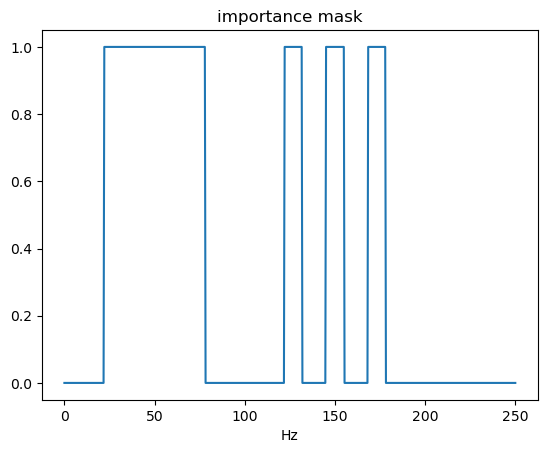

In [39]:
plt.plot(freqs, mask); plt.xlabel('Hz'); plt.title('importance mask')

### Binary Classification

In [40]:
from src.models import ResNet, ResidualBlock
from src.train import train_resnet_model
from src.inference import inference_resnet_model
from src.evaluation import calculate_metrics
from sklearn.metrics import classification_report
from src.train import train_resnet_epoch_cached

In [41]:
mask_torch = torch.tensor(mask, dtype=torch.float32)[None,None,:].to(device)

model_bin = ResNet(
    ResidualBlock, [2,2,2,2],
    num_classes = 2,
    dropout_rate= 0.2,
    # BandWeightAttention
    prior_kwargs = dict(
        mask          = mask_torch,
        w_in_init     = 1.2,    # neutral start inside bands
        w_out_init    = 0.0,    # hard zero outside
        learnable_in  = True,   # let the model boost inside if it wants
        learnable_out = False,  # keep outside at 0
    )
).to(device)

In [43]:
print("Training ResNet for binary classification...")

model_bin = train_resnet_epoch_cached(
    model            = model_bin,
    cached_dataset   = datasets_binary['train'],
    val_loader       = val_loader_binary,
    device           = device,
    num_epochs       = num_epochs_binary,
    batch_size       = batch_size,
    initial_lr       = 1e-3,
    patience         = 15,
    checkpoint_path  = "../res/checkpoints/"
)

Training ResNet for binary classification...


Epoch 1/20:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch [1/20] train-loss: 0.0221  acc: 99.29%
  → val-loss: 1.5169  acc: 56.39%
[✓]   New best (binary) saved →  ../res/checkpoints/resnet_best_binary.pth  (metric=0.5639)
  [✓] best model saved → ../res/checkpoints/


Epoch 2/20:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch [2/20] train-loss: 0.0025  acc: 99.93%
  → val-loss: 0.3953  acc: 80.78%
[✓]   New best (binary) saved →  ../res/checkpoints/resnet_best_binary.pth  (metric=0.8078)
  [✓] best model saved → ../res/checkpoints/


...

Epoch [18/20] train-loss: 0.0010  acc: 99.97%
  → val-loss: 0.3854  acc: 87.10%


Epoch 19/20:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch [19/20] train-loss: 0.0013  acc: 99.97%
  → val-loss: 0.6349  acc: 81.04%


Epoch 20/20:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch [20/20] train-loss: 0.0015  acc: 99.96%
  → val-loss: 0.5006  acc: 85.84%


In [44]:
true_labels_bin, predictions_bin = inference_resnet_model(model_bin, test_loader_binary, device=device)

Inference:   0%|          | 0/8 [00:00<?, ?batch/s]

In [45]:
# Calculate metrics 
cm_bin, acc_bin, prec_bin, rec_bin, f1_bin = calculate_metrics(true_labels_bin, predictions_bin)

In [46]:
binary_report = classification_report(true_labels_bin, predictions_bin, target_names=['normal', 'anomalous'])
print(binary_report)

              precision    recall  f1-score   support

      normal       0.95      1.00      0.98      2016
   anomalous       1.00      0.95      0.98      2016

    accuracy                           0.98      4032
   macro avg       0.98      0.98      0.98      4032
weighted avg       0.98      0.98      0.98      4032



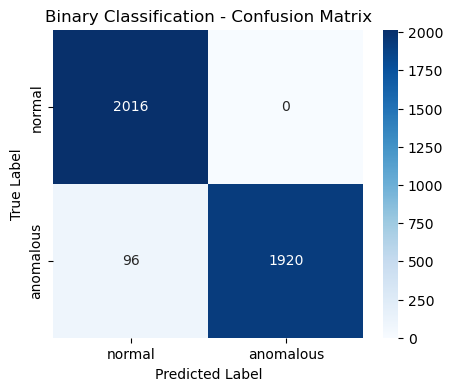

In [47]:
fig_bin, ax_bin = plt.subplots(figsize=(5,4))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues',
            xticklabels=['normal','anomalous'], yticklabels=['normal','anomalous'], ax=ax_bin)
ax_bin.set_xlabel('Predicted Label')
ax_bin.set_ylabel('True Label')
ax_bin.set_title('Binary Classification - Confusion Matrix')
plt.show()

In [48]:
predictions_bin = np.asarray(predictions_bin, dtype=np.int64) 

test_idx_bin = datasets_binary["test_idx"]           
meta_test_bin = seg_meta_df.loc[test_idx_bin].copy()
meta_test_bin["binary_prediction"] = predictions_bin
assert len(predictions_bin) == meta_test_bin.shape[0]

# human‑readable version
meta_test_bin["binary_prediction_state"] = np.where(
    predictions_bin == 0, "normal", "anomalous"
)

bin_path = os.path.join(base_dir, "segments_metadata_test_binary_pred.csv")
meta_test_bin.to_csv(bin_path, index=True)
print(f"Binary test predictions saved to: {bin_path}")

Binary test predictions saved to: ../dataset/engine_2/segments_metadata_test_binary_pred.csv


### Multiclass Classification

In [49]:
num_classes_multi = len(datasets_multi['label_encoder'].classes_)
model_multi = ResNet(
    ResidualBlock, [2,2,2,2],
    num_classes = num_classes_multi,
    dropout_rate= 0.2,
    # BandWeightAttention
    prior_kwargs = dict(
        mask          = mask_torch,
        w_in_init     = 1.2,    # neutral start inside bands
        w_out_init    = 0.0,    # hard zero outside
        learnable_in  = True,   # let the model boost inside if it wants
        learnable_out = False,  # keep outside at 0
    )
).to(device)

In [50]:
print("Training ResNet for multiclass classification...")

model_multi = train_resnet_epoch_cached(
    model            = model_multi,
    cached_dataset   = datasets_multi['train'],
    val_loader       = val_loader_multi,
    device           = device,
    num_epochs       = num_epochs_multi,
    batch_size       = batch_size,
    initial_lr       = 1e-3,
    patience         = 15,
    checkpoint_path  = "../res/checkpoints/resnet_best_multi.pth"
)

Training ResNet for multiclass classification...


Epoch 1/20:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch [1/20] train-loss: 0.2781  acc: 89.91%
  → val-loss: 2.8156  acc: 49.59%
[✓]   New best (multiclass) saved →  ../res/checkpoints/resnet_best_multi.pth/resnet_best_multiclass.pth  (metric=0.4959)
  [✓] best model saved → ../res/checkpoints/resnet_best_multi.pth


Epoch 2/20:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch [2/20] train-loss: 0.0100  acc: 99.72%
  → val-loss: 4.5982  acc: 33.38%


...

Epoch [18/20] train-loss: 0.0041  acc: 99.89%
  → val-loss: 1.1021  acc: 72.04%


Epoch 19/20:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch [19/20] train-loss: 0.0018  acc: 99.96%
  → val-loss: 0.6501  acc: 82.03%


Epoch 20/20:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch [20/20] train-loss: 0.0015  acc: 99.97%
  → val-loss: 0.5133  acc: 84.71%


In [51]:
# Save label encoder
import joblib

enc = datasets_multi["label_encoder"]
save_dir = Path("../res/label_encoders")
save_dir.mkdir(parents=True, exist_ok=True)

enc_path = save_dir / "label_encoder_multiclass.pkl"
joblib.dump(enc, enc_path, compress=3)

print(f"[✓]  Saved LabelEncoder with classes → {list(enc.classes_)}\n"
      f"     to {enc_path.resolve()}")

[✓]  Saved LabelEncoder with classes → ['inter-turn short circuits', 'normal', 'rotor bar defect']
     to /Users/kgb/Yandex.Disk.localized/Code/Motor-Fault-Detection/res/label_encoders/label_encoder_multiclass.pkl


In [52]:
true_labels_multi, predictions_multi = inference_resnet_model(model_multi, test_loader_multi, device=device)

Inference:   0%|          | 0/12 [00:00<?, ?batch/s]

In [53]:
# Calculate metrics 
cm_multi, acc_multi, prec_multi, rec_multi, f1_multi = calculate_metrics(true_labels_multi, predictions_multi)

In [54]:
multiclass_report = classification_report(true_labels_multi, predictions_multi, target_names=datasets_multi['label_encoder'].classes_, output_dict=True)
multiclass_report_prefixed = {f"multiclass_{key}": value for key, value in multiclass_report.items()}

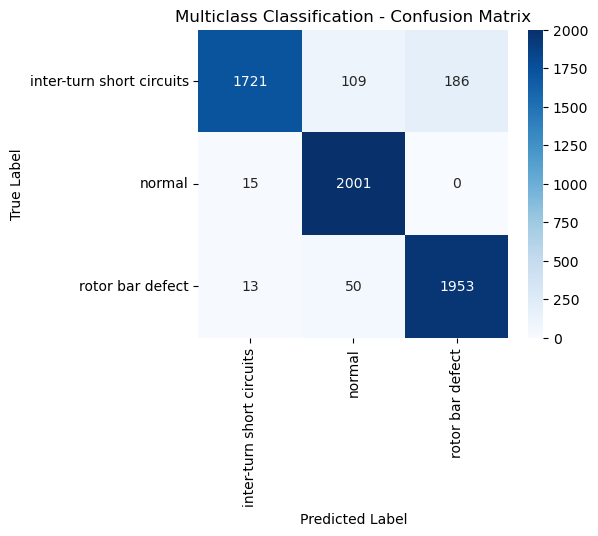

In [55]:
fig_multi, ax_multi = plt.subplots(figsize=(5,4))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=datasets_multi['label_encoder'].classes_,
            yticklabels=datasets_multi['label_encoder'].classes_, ax=ax_multi)
ax_multi.set_xlabel('Predicted Label')
ax_multi.set_ylabel('True Label')
ax_multi.set_title('Multiclass Classification - Confusion Matrix')
plt.show()

In [56]:
predictions_multi = np.asarray(predictions_multi, dtype=np.int64) 

test_idx_multi = datasets_multi["test_idx"]
meta_test_multi = seg_meta_df.loc[test_idx_multi].copy()
assert len(predictions_multi) == meta_test_multi.shape[0]

# decode integer predictions back to fault names
pred_labels_multi = datasets_multi["label_encoder"].inverse_transform(predictions_multi)
meta_test_multi["multiclass_prediction"] = pred_labels_multi

multi_path = os.path.join(base_dir, "segments_metadata_test_multiclass_pred.csv")
meta_test_multi.to_csv(multi_path, index=True)
print(f"Multiclass test predictions saved to: {multi_path}")

Multiclass test predictions saved to: ../dataset/engine_2/segments_metadata_test_multiclass_pred.csv
